# 1.환경준비

In [1]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format = 'retina'

In [2]:
df = pd.read_csv("data/titanic_train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 2.데이터 이해

In [3]:
# 상위 몇 개 행 확인
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# 변수 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
# 기초 통계
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


# 3. 데이터 전처리

**1) 변수 제거**

In [8]:
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']

df.drop(drop_cols, axis=1, inplace=True)

**2) 결측치 처리**

In [9]:
# Age 결측치 중앙값으로 채움
age_median = df['Age'].median()
df['Age'].fillna(age_median, inplace=True)

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [10]:
# Embarked 최빈값으로 채우기
emb_freq = df['Embarked'].mode()[0]
df['Embarked'].fillna(emb_freq, inplace=True)

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

**3) x, y 분리**

In [11]:
target = 'Survived'

X = df.drop(target, axis=1)
y = df[target]

**4) 가변수화**

In [12]:
dumm_cols = ['Pclass', 'Sex', 'Embarked']

X = pd.get_dummies(X, columns=dumm_cols, drop_first=True)

X.head()

,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,22.0,1,0,7.2500,False,True,True,False,True
1,38.0,1,0,71.2833,False,False,False,False,False
2,26.0,0,0,7.9250,False,True,False,False,True
3,35.0,1,0,53.1000,False,False,False,False,True
4,35.0,0,0,8.0500,False,True,True,False,True


**5) 학습용, 평가용 데이터 분리**

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=11)

# 4.모델링

In [14]:
# 1단계: 불러오기
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [15]:
# 2단계: 선언하기
model = DecisionTreeClassifier(max_depth=5)

In [16]:
# 3단계: 학습하기
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [17]:
# 4단계: 예측하기
y_pred = model.predict(X_test)

## 4.1.Confusion Matrix : 오차행렬

In [18]:
# 5단계 평가하기
# 예측결과와 실제 결과의 오차행렬 출력
print(confusion_matrix(y_test, y_pred))

[[167   9]
 [ 36  56]]


## 4.2.정밀도(Prescision) 재현율(Recall) 구해보기

In [19]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, classification_report

print("정밀도 : ", precision_score(y_test, y_pred))
print("재현율 : ", recall_score(y_test, y_pred))

정밀도 :  0.8615384615384616
재현율 :  0.6086956521739131


In [20]:
# 함수로 만들어보기

def metrics_eval(y_test, pred):
    print("정확도 : ", accuracy_score(y_test, pred))
    print("정밀도 : ", precision_score(y_test, pred))
    print("재현율 : ", recall_score(y_test, pred))
    print("오차행렬 : ", confusion_matrix(y_test, pred))
    print("f1-score : ", f1_score(y_test, pred))
    print("전체 결과 : ", classification_report(y_test, pred))

In [21]:
metrics_eval(y_test, y_pred)

정확도 :  0.832089552238806
정밀도 :  0.8615384615384616
재현율 :  0.6086956521739131
오차행렬 :  [[167   9]
 [ 36  56]]
f1-score :  0.7133757961783439
전체 결과 :                precision    recall  f1-score   support

           0       0.82      0.95      0.88       176
           1       0.86      0.61      0.71        92

    accuracy                           0.83       268
   macro avg       0.84      0.78      0.80       268
weighted avg       0.84      0.83      0.82       268



## 4.3.정밀도 재현율 트레이드오프
- 정밀도(Precision)와 재현율(Recall)은 서로 상충(trade-off)하는 관계를 가진다.
- 즉, 정밀도를 높이면 재현율이 낮아지고, 재현율을 높이면 정밀도가 낮아지는 경향이 있다.
- 예) 모델이 "긍정(Positive)"이라고 예측할 기준을 엄격하게 설정하면, 잘못된 긍정(FP)은 줄어들지만, 긍정을 아예 놓쳐버릴(FN 증가) 가능성이 커짐
- 특정 문제에서는 정밀도를 우선할지, 재현율을 우선할지 결정해야 함
- 비즈니스와 도메인 요구사항에 따라 적절한 균형(F1-score)을 찾는 것이 중요

In [22]:
pred_proba = model.predict_proba(X_test)    # 분류 모델(Classifier)이 각 클래스에 대한 예측 확률(probability)을 반환하는 함수
pred = model.predict(X_test)

In [23]:
# 예측 확률 배열의 형태 확인 (샘플 개수, 클래스 개수)
pred_proba.shape

(268, 2)

In [24]:
# np.concatenate()를 사용하여 예측 확률과 최종 예측값을 나란히 배치하기 위해 (샘플 개수, 1) 형태로 변환
pred.reshape(-1, 1).shape

(268, 1)

In [25]:
# 한눈에 확인해보기
# 배열 구조 [클래스1 예측 확률, 클래스2 예측 확률, 예측 클래스]
pred_proba_result = np.concatenate([pred_proba, pred.reshape(-1, 1)], axis=1)
pred_proba_result[:10]

array([[0.23684211, 0.76315789, 1.        ],
       [0.84782609, 0.15217391, 0.        ],
       [0.92857143, 0.07142857, 0.        ],
       [0.84782609, 0.15217391, 0.        ],
       [0.57954545, 0.42045455, 0.        ],
       [0.84782609, 0.15217391, 0.        ],
       [0.92857143, 0.07142857, 0.        ],
       [0.23684211, 0.76315789, 1.        ],
       [0.84782609, 0.15217391, 0.        ],
       [0.12121212, 0.87878788, 1.        ]])

## 4.4.precision_recall_curve() 확인해보기

In [26]:
from sklearn.metrics import precision_recall_curve

# 레이블이 1일때의 예측 확률을 추출
pred_proba_class1 = model.predict_proba(X_test)[:, 1]

In [27]:
# Precision-Recall Curve 계산
# thresholds: Precision과 Recall을 계산한 다양한 임곗값 리스트
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_class1)

In [28]:
# 임곗값(Threshold)에 따라 Precision이 어떻게 변하는지 확인 가능
precisions

array([0.34328358, 0.35856574, 0.43915344, 0.71962617, 0.72115385,
       0.73033708, 0.86153846, 0.92      , 0.91891892, 1.        ])

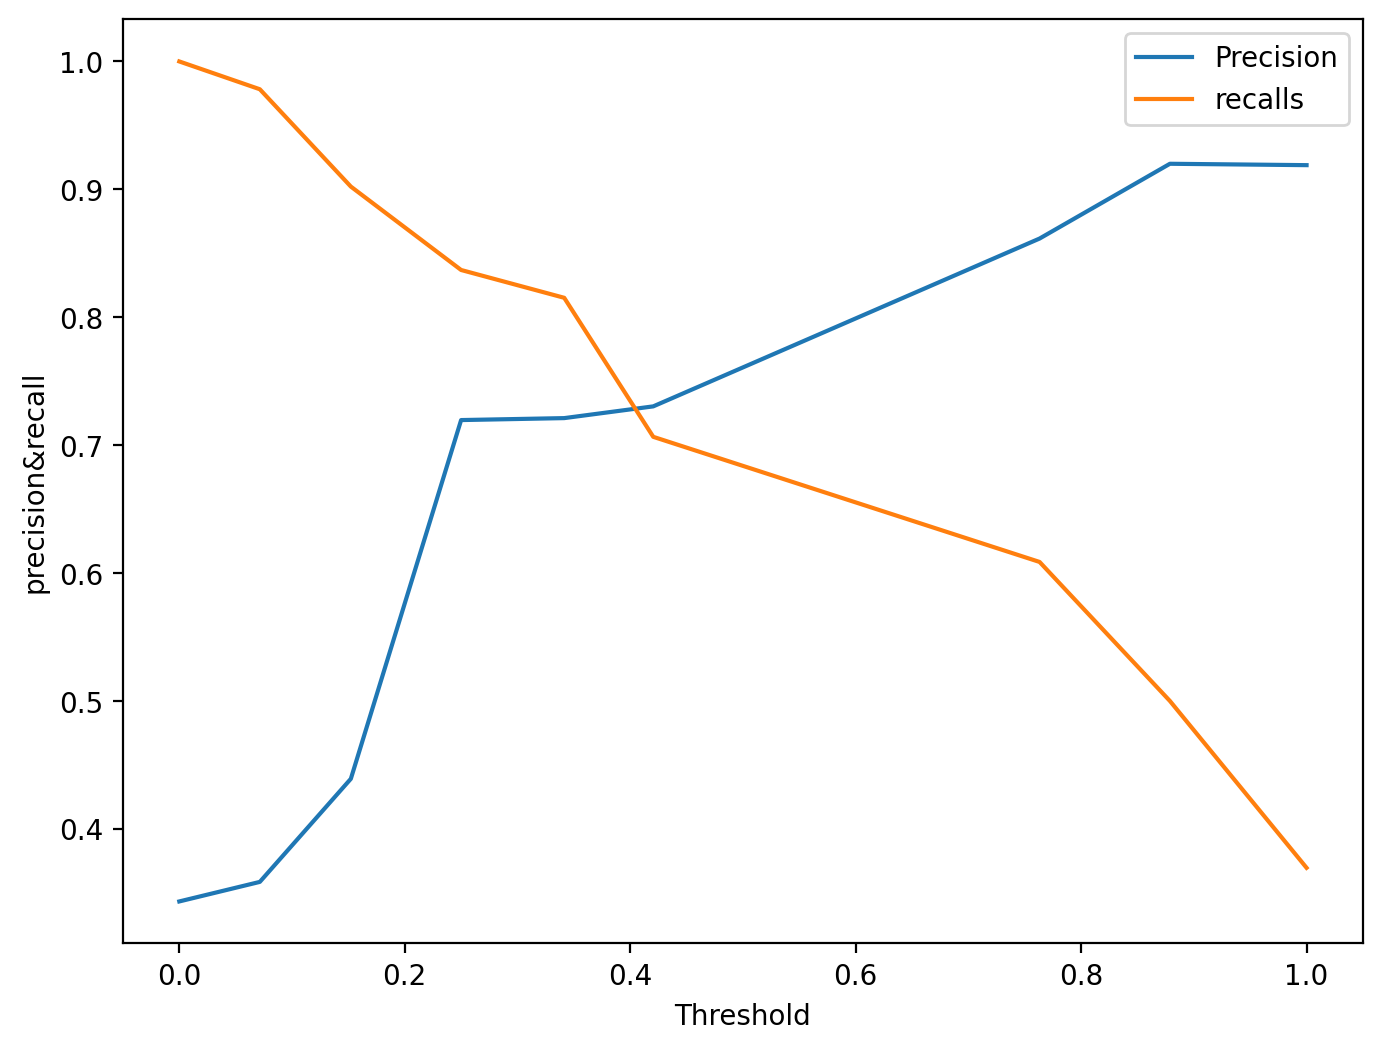

In [29]:
# 차트로 그려보기
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="recalls")
plt.xlabel("Threshold")
plt.ylabel("precision&recall")
plt.legend()
plt.show()

- 비즈니스 목표에 따라 Precision과 Recall 중 무엇을 우선할지 정해야 한다.
    - 정밀도(Precision)를 우선하는 경우
    - 잘못된 긍정 예측(False Positive, FP)을 줄이는 것이 중요한 경우
        - 예: 사기 탐지, 암 진단, 위험한 상황 감지
    - 재현율(Recall)을 우선하는 경우
    - 실제 양성(True Positive)을 놓치는 것이 치명적인 경우
        - 예: 스팸 필터링, 질병 진단, 불량품 검사

 ## 4.5.Roc 곡선과 AUC 점수를 그래프로 나타내기
- ROC(Receiver Operating Characteristic) 곡선은 분류 모델의 성능을 평가하는 그래프이다.
- 이 곡선은 모델의 민감도(Sensitivity, TPR, True Positive Rate) 와 1-특이도(1-Specificity, FPR, False Positive Rate) 를 다양한 기준(Threshold) 값에 따라 변화시키면서 그리는 그래프이다.



 - FPR(False Positive Rate) : 실제 네거티브인 샘플 중에서 Positive 로 잘못 예측한 비율
 - TPR(True Positive Rate) : 실제 Positive 인 샘플중에서 제대로 예측한 비율 : 재현율
 - AUC : ROC 곡선의 아래면적을 뜻함.

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC curve 를 위한 FPR, TPR 계산
fprs, tprs, roc_thresholds = roc_curve(y_test, y_pred)

In [31]:
# AUC 점수를 계산
# AUC 값이 1에 가까울수록 모델 성능이 좋음 (최대 1, 랜덤이면 0.5)
roc_auc = roc_auc_score(y_test, pred_proba_class1)      # AUC(ROC 곡선 아래 면적)를 계산
print("roc_auc 점수는 :", roc_auc)

roc_auc 점수는 : 0.8573369565217392


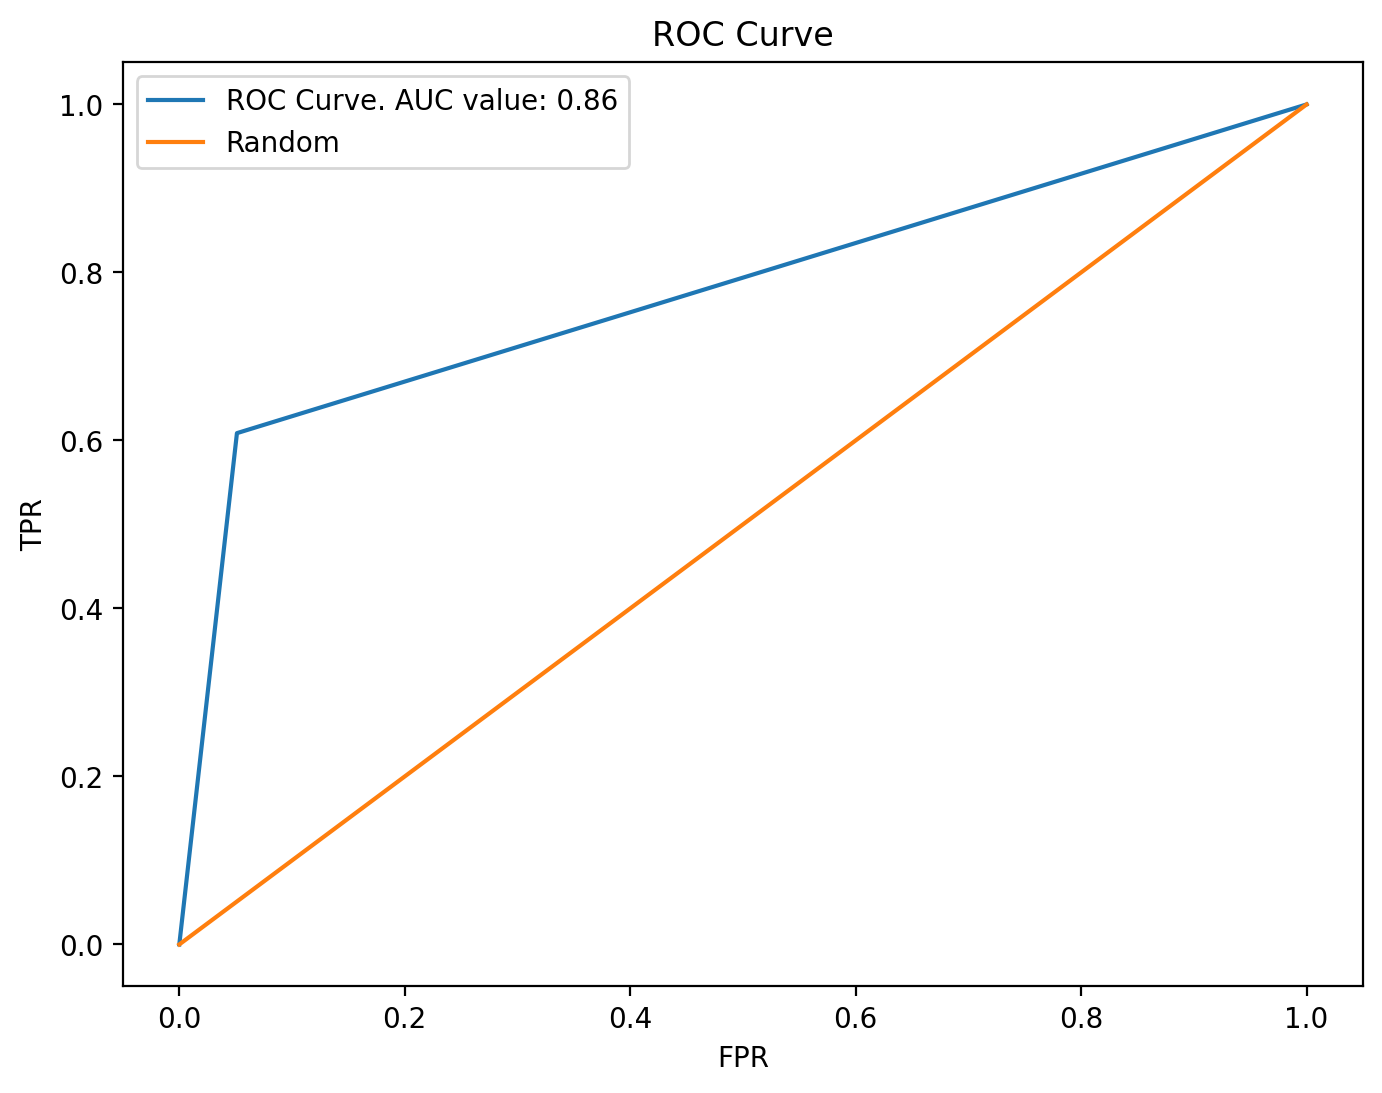

In [32]:
## 차트 그려보기
plt.figure(figsize=(8, 6))
plt.plot(fprs, tprs, label=f"ROC Curve. AUC value: {roc_auc:.2f}")
plt.plot([0,1], [0, 1], label="Random")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()